## libs import

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## connection

In [10]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

## query for date from checker for users

In [11]:
query = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.read_sql_query(query, connection)
df['date'] = pd.to_datetime(df['timestamp']).dt.date
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
df.drop('timestamp', axis=True, inplace=True)

## df preprocessing

In [12]:
df_commits_counts = pd.DataFrame(df.value_counts()).reset_index()
df_commits_counts['weekday'] = pd.to_datetime(df_commits_counts['date'], format = "%Y:%m:%d").dt.weekday
df_commits_counts['is_workday'] = (df_commits_counts.weekday<5)*1

In [16]:
df_grouping = df_commits_counts[df_commits_counts['count'] > 0][['hour', 'count', 'is_workday']].groupby(['hour', 'is_workday']).sum().reset_index()

In [19]:
df_grouping.sort_values(by = 'count', ascending=False).head()

,hour,is_workday,count
37,21,1,292
33,19,1,214
29,17,1,192
35,20,1,183
27,16,1,170


## create two dfs: for working day and weekend

In [30]:
is_workday = df_grouping.query('is_workday == 0').reset_index().set_index('hour')[['count']]
is_weekend = df_grouping.query('is_workday == 1').reset_index().set_index('hour')[['count']]

In [31]:
is_workday.sort_values(by = 'count', ascending=False).head()

,count
hour,
11,118
20,117
15,114
13,108
19,105


In [32]:
is_weekend.sort_values(by = 'count', ascending=False).head()

,count
hour,
21,292
19,214
17,192
20,183
16,170


## Plot. Commits per hour

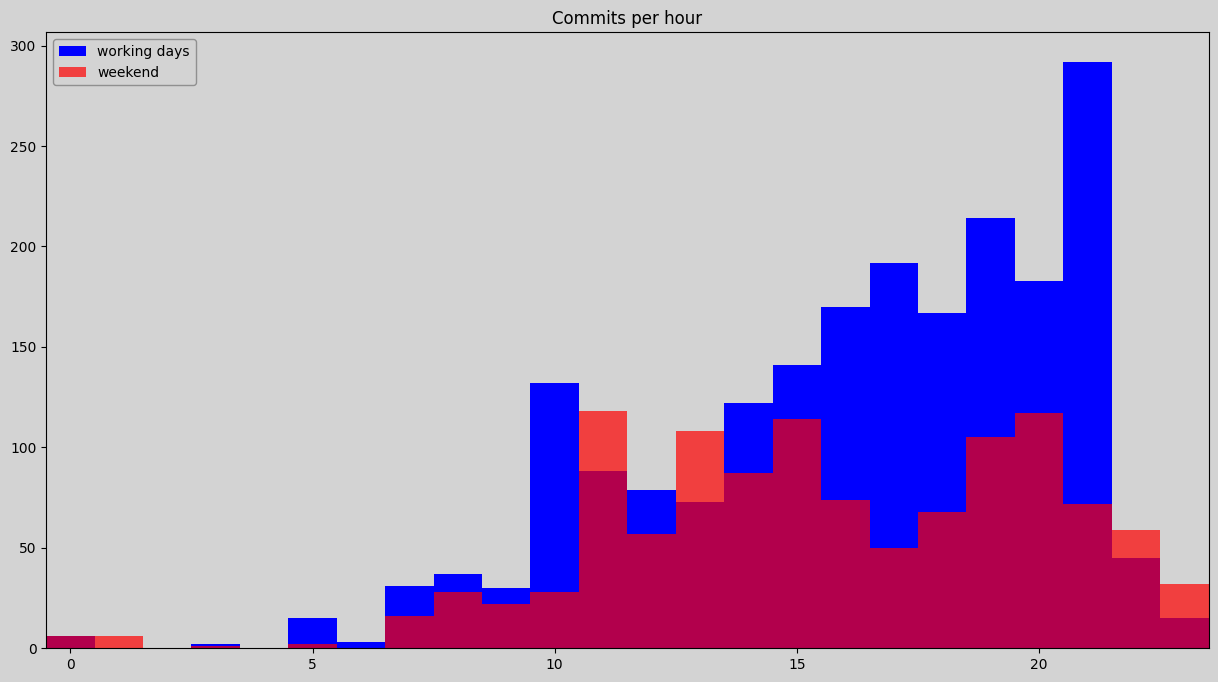

In [53]:
plt.figure(figsize=(15, 8))
plt.bar(is_weekend.index, is_weekend['count'], alpha=1, label='working days', color='blue', width=1)
plt.bar(is_workday.index, is_workday['count'], alpha=0.7, label='weekend', color='red', width=1)

# Добавление заголовка и меток
plt.title('Commits per hour')

plt.gcf().set_facecolor('lightgray')
plt.gca().set_facecolor('lightgray')
plt.gca().set_xlim(left=0)
plt.gca().autoscale(enable=True, axis='x', tight=True)
# Отображение легенды
legend = plt.legend(loc='upper left')
legend.get_frame().set_facecolor('lightgray')  # Серый фон
legend.get_frame().set_edgecolor('grey')      # Черная рамка

# Показать график
plt.show()

## Answer for question:

### “Are there hours when the total number of commits was higher on weekends than on working days?”. Put the top-4 examples
### The answer is 13, 11, 23, 22

## connection close

In [54]:
connection.close()